In [1]:
import torch

from src.distributions.star_gaussians import StarGaussian

# seed
torch.manual_seed(31)

In [2]:
# construct a bimodal radial function
class BimodalRho(torch.nn.Module):
    def __init__(self):
        super().__init__()

        self.Sigma_1 = torch.tensor([3.0, 0.5])
        self.Sigma_2 = torch.tensor([0.5, 3.0])
        self.mu_1 = torch.tensor([0.0, 0.0])
        self.mu_2 = torch.tensor([0.0, 0.0])

    def forward(self, theta):
        """
        
        :param theta: N x d tensor with ||theta|| = 1
        :return: N tensor
        """

        rho_1 = 1/torch.norm((theta - self.mu_1[None]) / self.Sigma_1[None], dim=-1) # large for theta - mu_1 aligned with x axis
        rho_2 = 1/torch.norm((theta - self.mu_2[None]) / self.Sigma_2[None], dim=-1)

        return rho_1 + rho_2
    
class BimodalStarGaussian(StarGaussian):
    def __init__(self):
        rho = BimodalRho()
        super().__init__(dim=2, rho=rho)
    
# construct normalizing flow
dist = BimodalStarGaussian()

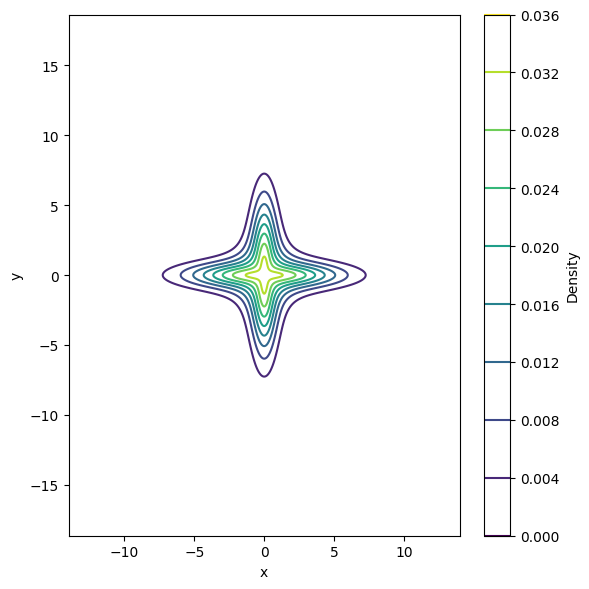

In [6]:
# plot density
import matplotlib.pyplot as plt

n_points = 1001
x = torch.linspace(-14, 14, n_points)
y = torch.linspace(-14, 14, n_points)
X, Y = torch.meshgrid(x, y)
XY = torch.stack([X.flatten(), Y.flatten()], dim=-1)
log_probs = torch.exp(dist.log_prob(XY).reshape(n_points, n_points).detach())

plt.figure(figsize=(6,6))
plt.contour(X.numpy(), Y.numpy(), log_probs.numpy(), levels=10, cmap='viridis')
plt.colorbar(label='Density')
plt.xlabel('x')
plt.ylabel('y')
plt.axis('equal')
plt.tight_layout()
plt.show()

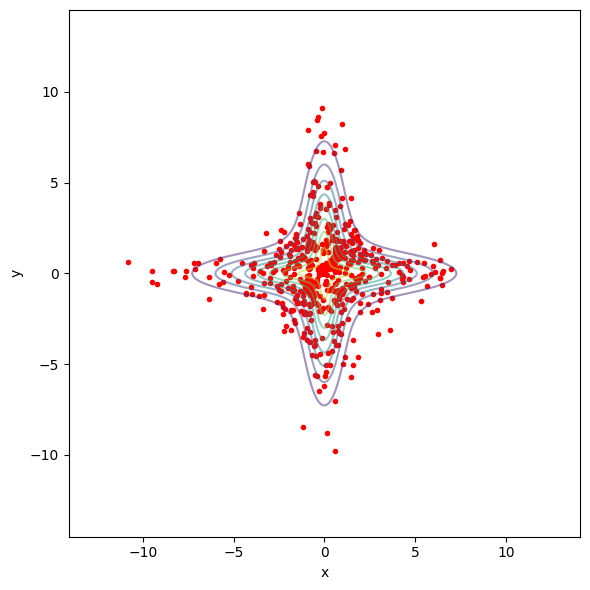

In [4]:
# generate samples
samples = dist.sample(500).detach().numpy()

plt.figure(figsize=(6,6))
plt.contour(X.numpy(), Y.numpy(), log_probs.numpy(), levels=10, cmap='viridis', alpha=0.5)
plt.scatter(samples[:,0], samples[:,1], marker='.', color='red')
plt.xlabel('x')
plt.ylabel('y')
plt.axis('equal')
plt.tight_layout()
plt.show()

In [8]:
# check normalization integrates to 1 by monte carlo from uniform samples
n_mc_samples = 1000000
mc_samples = (torch.rand(n_mc_samples, 2) - 0.5) * 28.0  # uniform in [-14, 14]^2
mc_log_probs = dist.log_prob(mc_samples)
mc_probs = torch.exp(mc_log_probs)
mc_integral = mc_probs.mean() * (28.0 ** 2)  # area of bounding box
print(f'Monte Carlo integral estimate: {mc_integral.item()}')


Monte Carlo integral estimate: 1.0199686288833618
